In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [74]:
df = pd.read_csv("Mall_Customers.csv")

In [75]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [76]:
df.drop("CustomerID", axis=1, inplace=True)

In [77]:
df["Gender"] = (df["Gender"] == "Female").astype("int8")

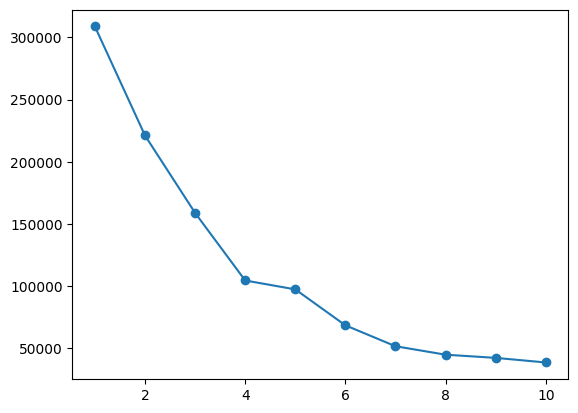

In [84]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')

In [100]:
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=5, random_state=42)
kmeans.fit(df)
y_pred = kmeans.predict(df)

In [101]:
y_kmeans

array([2, 2, 0, 1, 1, 1, 0, 1, 3, 1, 3, 1, 0, 1, 3, 2, 0, 2, 3, 1, 3, 2,
       0, 2, 0, 2, 0, 2, 0, 1, 3, 1, 3, 2, 0, 1, 0, 1, 0, 1, 0, 2, 3, 1,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 3, 0, 3, 0, 3, 1, 3, 3, 2, 0, 0, 3, 2,
       0, 0, 2, 1, 3, 0, 0, 0, 3, 2, 0, 3, 1, 0, 3, 2, 3, 0, 1, 3, 0, 1,
       1, 0, 0, 2, 3, 0, 1, 2, 0, 1, 3, 2, 1, 0, 3, 2, 3, 1, 0, 3, 3, 3,
       3, 1, 0, 2, 1, 1, 0, 0, 0, 0, 2, 0, 1, 2, 1, 1, 3, 2, 3, 2, 3, 2,
       1, 1, 3, 1, 0, 2, 3, 1, 0, 2, 1, 1, 3, 2, 3, 1, 0, 2, 3, 2, 0, 1,
       0, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 0, 2, 3, 2, 3, 2, 0, 1,
       3, 2, 3, 2, 0, 1, 3, 1, 0, 2, 0, 2, 0, 1, 0, 1, 3, 1, 0, 1, 0, 2,
       3, 2], dtype=int32)

Text(0, 0.5, 'Spending Score (1-100)')

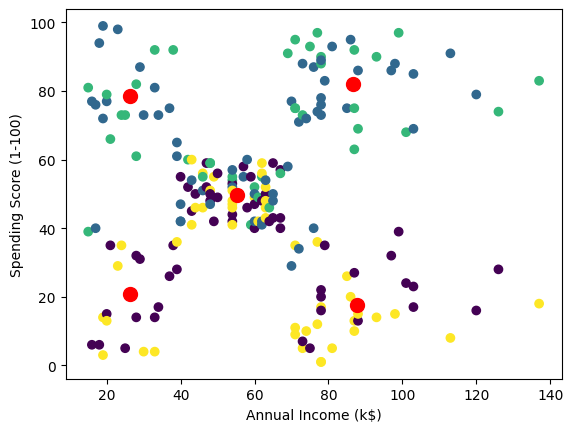

In [102]:
plt.scatter(df.iloc[:, 2], df.iloc[:, 3], c=y_kmeans, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s=100, c='red', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')